# Task ONE: Implementation of the ANN architecture

### Porblem Statement summary

- The goal is to train a model on review data to automate the current manual process, which is labor-intensive and inefficient.
- This notebook implements and compares three different models for text classification:
    * MLP (Multi-Layer Perceptron)
    * CNN (Convolutional Neural Network)
    * RNN (Recurrent Neural Network)
- The models are trained and tested on text data provided in the dataset.

### Methodology

1. Import Dependencies – Load necessary libraries and modules.
2. Data Preprocessing – Clean, tokenize, and prepare the text data.
3. Model Compilation – Build and train the models.
4. Result Analysis – Evaluate the models’ performance.
5. Comparative Analysis and experimentation – Compare results across different models.

# Data manipluation

In [31]:
!c:\Users\jorda\AppData\Local\Programs\Python\Python311\python.exe -m pip install --user seaborn


     -------------------------------------- 294.9/294.9 kB 3.0 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
# imports

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tqdm.keras import TqdmCallback
# Cnn model dependencies
from tensorflow import keras
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, Flatten, Dense
# RNN model dependencies
from tensorflow.keras.layers import LSTM

from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.feature_extraction.text import TfidfVectorizer # for vectorising the text

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import itertools
import seaborn as sns

In [ ]:
# Load the dataset
train_df = pd.read_csv("./train.csv")
test_df = pd.read_csv("./test-1.csv")

print(train_df.head())


In [ ]:
# Converting the text to lower case for easier classifiaction

train_df['clean_text'] = train_df['text'].str.lower()
test_df['clean_text'] = test_df['text'].str.lower()

In [ ]:
train_df['clean_text'] = train_df['clean_text'].str.replace(r'[^\w\s]', '', regex=True)
test_df['clean_text'] = test_df['clean_text'].str.replace(r'[^\w\s]', '', regex=True)

train_df['clean_text'] = train_df['clean_text'].str.replace(r'\d+', '', regex=True)
test_df['clean_text'] = test_df['clean_text'].str.replace(r'\d+', '', regex=True)


In [ ]:
train_df['clean_text'] = train_df['clean_text'].str.strip().replace(r'\s+', ' ', regex=True)
test_df['clean_text'] = test_df['clean_text'].str.strip().replace(r'\s+', ' ', regex=True)


In [ ]:
# removing the stop words to make classifiaction easier
stopwords_list = ["the", "is", "in", "and", "to", "of", "it", "a", "this", "for", "with"]  

train_df['clean_text'] = train_df['clean_text'].apply(lambda x: ' '.join([word for word in x.split() if word not in stopwords_list]))
test_df['clean_text'] = test_df['clean_text'].apply(lambda x: ' '.join([word for word in x.split() if word not in stopwords_list]))


In [ ]:
# For MLP creating a vector 

# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)  # Limit vocabulary size

# Fit and transform the text data
train_tfidf = tfidf_vectorizer.fit_transform(train_df['clean_text'])
test_tfidf = tfidf_vectorizer.transform(test_df['clean_text'])

# Convert to DataFrame for inspection
train_tfidf_df = pd.DataFrame(train_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
test_tfidf_df = pd.DataFrame(test_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())




In [ ]:
pd.set_option('display.max_rows', None)  # Show all rows


test_tfidf_df

In [ ]:
# For CNN and RNN creating a Tokeniser and Embedding Layer
# Tokenization
max_vocab_size = 5000  # Limit vocabulary
tokenizer = Tokenizer(num_words=max_vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['clean_text'])

# Convert text to sequences
train_sequences = tokenizer.texts_to_sequences(train_df['clean_text'])
test_sequences = tokenizer.texts_to_sequences(test_df['clean_text'])

# Padding sequences
max_sequence_length = 100  # Standardizing length
train_padded = pad_sequences(train_sequences, maxlen=max_sequence_length, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=max_sequence_length, padding='post', truncating='post')

# Convert to DataFrame for inspection
train_padded_df = pd.DataFrame(train_padded)
test_padded_df = pd.DataFrame(test_padded)

# Display processed data



In [ ]:

test_padded_df

# MODEL 1: Implementation of the MLP model


In [ ]:
# Converting the TF-IDF sparse matric into a dense Numpy  array
x_train = train_tfidf_df.to_numpy()
x_test = test_tfidf_df.to_numpy()
y_train = train_df['label'].values
y_test = test_df['label'].values

# Building the model
tf.keras.utils.set_random_seed(0)

mlp_model = keras.Sequential([
    Dense(
        8, 
        input_dim=x_train.shape[1], 
        activation='relu', 
        kernel_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1)),
    Dense(
        4, 
        activation='relu', 
        kernel_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1)),
    Dense(
        1, 
        activation='sigmoid', 
        kernel_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1))
])

In [ ]:
# Compiling the model

#setting varibales for mlp model
learning_rates = [0.01, 0.05, 0.1]
loss = 'binary_crossentropy'
metrics = ['accuracy']

# setting varibales for Mlp history
epochs = 500
batch_size = 64
validation_data = (x_test, y_test)
verbose = 0

mlp_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate= Learning_rate),
    loss = loss,
    metrics = metrics
)

history = mlp_model.fit(
    x_train,
    y_train,
    epochs = epochs,
    batch_size = batch_size,
    validation_data = validation_data,
    verbose = verbose,
    callbacks=[TqdmCallback()]
)

In [ ]:
loss, accuracy = mlp_model.evaluate(x_test, y_test, verbose=1)
print(f"Test Accuracy: {accuracy:.4f}")

# Hyperparameters For both CNN and RNN

In [ ]:
# Shared hyperparameters for CNN & RNN models
input_dim = 5000  # Vocabulary size
embedding_dim = 128  # Dimension of word embeddings
sequence_length = 100  # Maximum sequence length
dense_units = 10  # Fully connected layer units
output_units = 1  # Output layer units
activation_output = 'sigmoid'  # Output activation function for binary classification
loss = 'binary_crossentropy'  # Loss function
metrics = ['accuracy']  # Evaluation metrics
optimizer = tf.keras.optimizers.Adam()  # Optimizer

# Training hyperparameters
epochs = 10  # Number of training iterations
batch_size = 64  # Batch size for training
validation_data = (test_padded, test_df['label'].values)  # Validation data
verbose = 0 # Verbosity mode for training output

# MODEL 2: Implementation of the CNN model

In [ ]:

# CNN-specific hyperparameters
filters = 128  # Number of filters in Conv1D
kernel_size = 5  # Kernel size for Conv1D
pool_size = 2  # Pool size for MaxPooling1D

# Define CNN model
cnn_model = keras.Sequential([
    Embedding(input_dim=input_dim, output_dim=embedding_dim, input_length=sequence_length),
    Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'),
    MaxPooling1D(pool_size=pool_size),
    Flatten(),
    Dense(dense_units, activation='relu'),
    Dense(output_units, activation=activation_output)
])

# Compile CNN model
cnn_model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Train CNN model
history_cnn = cnn_model.fit(
    train_padded, train_df['label'].values,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=validation_data,
    verbose=verbose,
    callbacks=[TqdmCallback()]
)

In [ ]:
loss, accuracy = cnn_model.evaluate(test_padded, test_df['label'].values, verbose=1)
print(f"Test Accuracy (CNN): {accuracy:.4f}")

# MODEL 3: Implementation of the RNN model

In [ ]:
input_dim = 5000  # Vocabulary size
embedding_dim = 128  # Dimension of word embeddings
sequence_length = 100  # Maximum sequence length
dense_units = 10  # Fully connected layer units
output_units = 1  # Output layer units
activation_output = 'sigmoid'  # Output activation function for binary classification
loss = 'binary_crossentropy'  # Loss function
metrics = ['accuracy']  # Evaluation metrics
optimizer = tf.keras.optimizers.Adam()  # Optimizer

epochs = 10  # Number of training iterations
batch_size = 64  # Batch size for training
validation_data = (test_padded, test_df['label'].values)  # Validation data
verbose = 0 # Verbosity mode for training output

# RNN-specific hyperparameters
rnn_units = 128  # LSTM units

# Define RNN model with LSTM
rnn_model = keras.Sequential([
    Embedding(input_dim=input_dim, output_dim=embedding_dim, input_length=sequence_length),
    LSTM(rnn_units, return_sequences=False),
    Dense(dense_units, activation='relu'),
    Dense(output_units, activation=activation_output)
])

# Compile RNN model
rnn_model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Train RNN model
history_rnn = rnn_model.fit(
    train_padded, train_df['label'].values,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=validation_data,
    verbose=verbose,
    callbacks=[TqdmCallback()]
)

In [ ]:
# Evaluate RNN model
loss, accuracy = rnn_model.evaluate(test_padded, test_df['label'].values, verbose=1)
print(f"Test Accuracy (RNN - LSTM): {accuracy:.4f}")

# Result analysis & Compariative analysis

# experimental analysis

In [28]:
learning_rates = [0.001, 0.01, 0.05]  
batch_sizes = [32, 64]
epochs_list = [10, 50]  

# Model types
model_types = ["MLP", "CNN", "RNN"]

# Store results
results = []

# Iterate over all hyperparameter combinations
for model_type, lr, batch_size, epochs in itertools.product(model_types, learning_rates, batch_sizes, epochs_list):
    
    print(f"\nTraining {model_type} Model | LR: {lr}, Batch: {batch_size}, Epochs: {epochs}")

    # Set optimizer
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    # Define model architecture
    if model_type == "MLP":
        model = keras.Sequential([
            Dense(8, input_dim=train_tfidf_df.shape[1], activation='relu'),
            Dense(4, activation='relu'),
            Dense(1, activation='sigmoid')
        ])
    
    elif model_type == "CNN":
        model = keras.Sequential([
            Embedding(input_dim=5000, output_dim=128, input_length=100),
            Conv1D(filters=128, kernel_size=5, activation='relu'),
            MaxPooling1D(pool_size=2),
            Flatten(),
            Dense(10, activation='relu'),
            Dense(1, activation='sigmoid')
        ])
    
    elif model_type == "RNN":
        model = keras.Sequential([
            Embedding(input_dim=5000, output_dim=128, input_length=100),
            LSTM(128, return_sequences=False),
            Dense(10, activation='relu'),
            Dense(1, activation='sigmoid')
        ])

    # Compile model
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    # Select training data based on model type
    if model_type == "MLP":
        x_train, x_test = train_tfidf_df.to_numpy(), test_tfidf_df.to_numpy()
    else:
        x_train, x_test = train_padded, test_padded
    
    y_train, y_test = train_df['label'].values, test_df['label'].values

    # Train model
    history = model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_test, y_test),
        verbose=0, callbacks=[TqdmCallback()]
    )

    # Evaluate model
    loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
    
    # Store results
    results.append({
        "Model": model_type,
        "Learning Rate": lr,
        "Batch Size": batch_size,
        "Epochs": epochs,
        "Accuracy": accuracy
    })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Display results in a table


100%|██████████| 50/50 [05:31<00:00,  6.62s/epoch, accuracy=0.504, loss=0.693, val_accuracy=0.518, val_loss=0.693]



Training RNN Model | LR: 0.001, Batch: 64, Epochs: 10


100%|██████████| 10/10 [01:00<00:00,  6.06s/epoch, accuracy=0.504, loss=0.693, val_accuracy=0.518, val_loss=0.693]



Training RNN Model | LR: 0.001, Batch: 64, Epochs: 50


100%|██████████| 50/50 [05:07<00:00,  6.15s/epoch, accuracy=0.504, loss=0.693, val_accuracy=0.518, val_loss=0.693]


...


Training RNN Model | LR: 0.05, Batch: 64, Epochs: 10


100%|██████████| 10/10 [00:55<00:00,  5.54s/epoch, accuracy=0.483, loss=0.695, val_accuracy=0.518, val_loss=0.693]



Training RNN Model | LR: 0.05, Batch: 64, Epochs: 50


100%|██████████| 50/50 [04:23<00:00,  5.26s/epoch, accuracy=0.484, loss=0.695, val_accuracy=0.518, val_loss=0.693]


ModuleNotFoundError: No module named 'ace_tools'

In [ ]:
model_ histories[f"{model_type}_LR{lr}_BS{batch_size}_E{epochs}"] = history.history

In [29]:
results_df

,Model,Learning Rate,Batch Size,Epochs,Accuracy
0,MLP,0.001,32,10,0.800797
1,MLP,0.001,32,50,0.786853
2,MLP,0.001,64,10,0.814741
3,MLP,0.001,64,50,0.792829
4,MLP,0.010,32,10,0.792829
5,MLP,0.010,32,50,0.794821
6,MLP,0.010,64,10,0.786853
7,MLP,0.010,64,50,0.784861
8,MLP,0.050,32,10,0.768924
9,MLP,0.050,32,50,0.790837


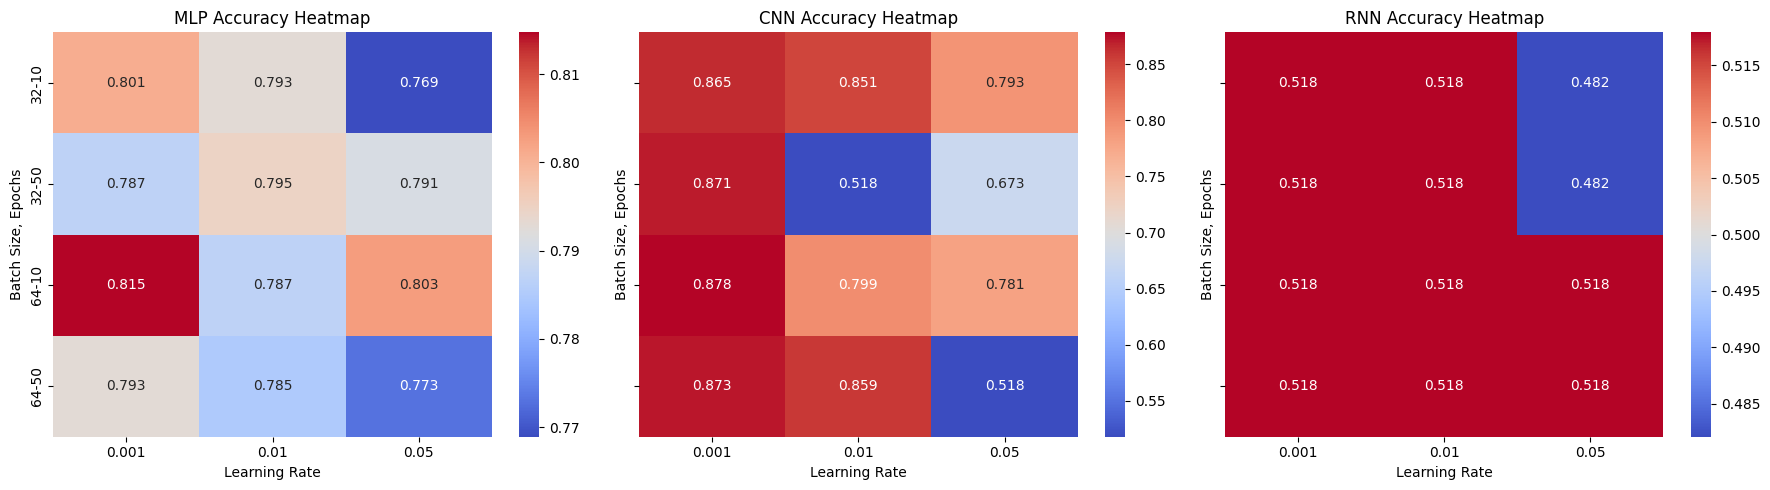

In [33]:
# Plotting heat maps

# Convert results to a format suitable for plotting
pivot_df = results_df.pivot_table(index=["Learning Rate", "Batch Size", "Epochs"], columns="Model", values="Accuracy")

# Set up the figure for subplots (one for each model)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Define model order for consistent comparison
model_order = ["MLP", "CNN", "RNN"]

# Plot heatmaps for each model
for i, model in enumerate(model_order):
    data = pivot_df[model].unstack(level=0)  # Reshape data for heatmap
    
    sns.heatmap(data, annot=True, fmt=".3f", cmap="coolwarm", ax=axes[i])
    axes[i].set_title(f"{model} Accuracy Heatmap")
    axes[i].set_xlabel("Learning Rate")
    axes[i].set_ylabel("Batch Size, Epochs")

# Adjust layout and show the plots
plt.tight_layout()
plt.show()


C:\Users\jorda\AppData\Local\Temp\ipykernel_21020\979460541.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_accuracies.index, y=mean_accuracies.values, palette="viridis")


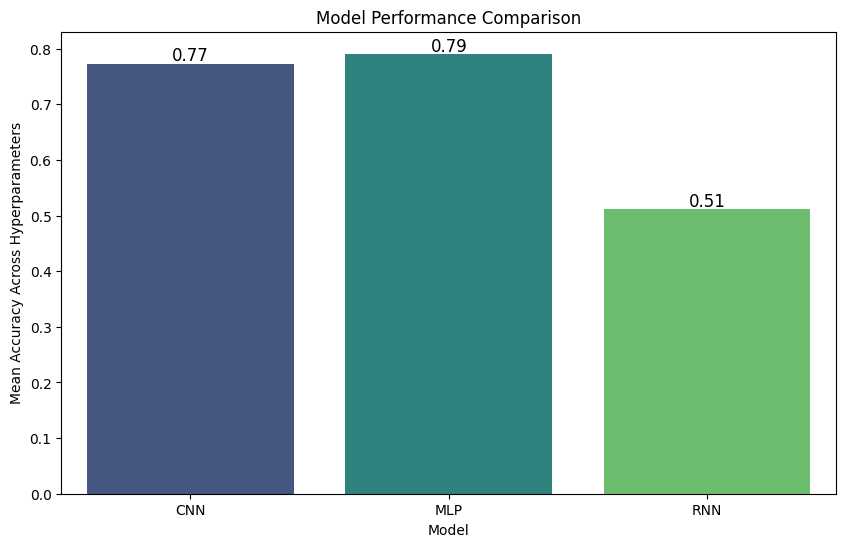

In [34]:
# Plotting a bar plot

# Bar chart comparing final model accuracies across different hyperparameters
plt.figure(figsize=(10, 6))

# Get mean accuracy for each model
mean_accuracies = results_df.groupby("Model")["Accuracy"].mean()

# Plot the bar chart
sns.barplot(x=mean_accuracies.index, y=mean_accuracies.values, palette="viridis")

# Labeling
plt.ylabel("Mean Accuracy Across Hyperparameters")
plt.title("Model Performance Comparison")

# Show values on bars
for index, value in enumerate(mean_accuracies.values):
    plt.text(index, value + 0.005, f"{value:.2f}", ha="center", fontsize=12)

# Show plot
plt.show()


TypeError: 'NoneType' object is not subscriptable

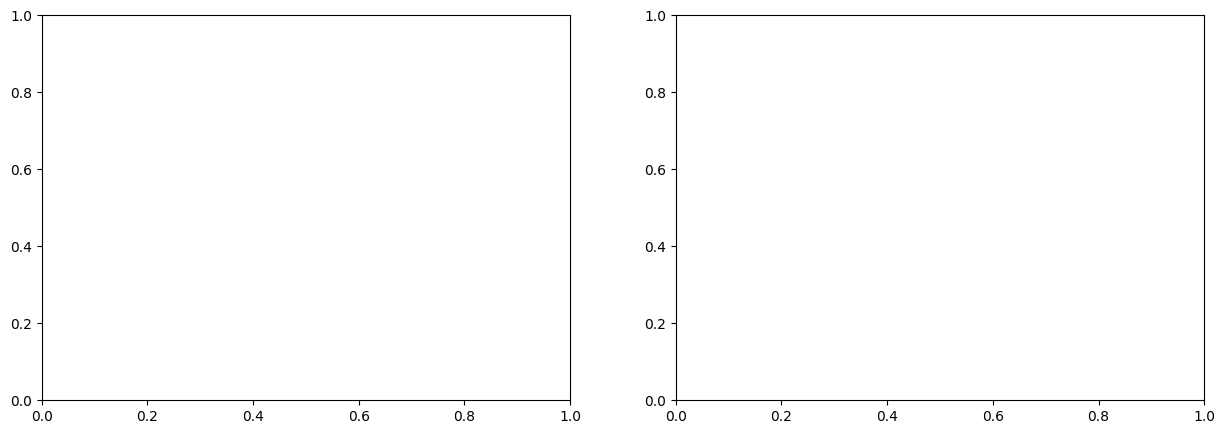

In [36]:
# Set up the plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot accuracy
for key, history in model_histories.items():
    axes[0].plot(history['accuracy'], label=f"{key} Train")
    axes[0].plot(history['val_accuracy'], linestyle="dashed", label=f"{key} Val")

axes[0].set_title("Model Accuracy Over Epochs")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

# Plot loss
for key, history in model_histories.items():
    axes[1].plot(history['loss'], label=f"{key} Train")
    axes[1].plot(history['val_loss'], linestyle="dashed", label=f"{key} Val")

axes[1].set_title("Model Loss Over Epochs")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

# Show the plots
plt.tight_layout()
plt.show()
